In [112]:
#py -m venv myenv
#.\myenv\Scripts\Activate
print("Hellow World!")

Hellow World!


In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from matplotlib import axes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

In [114]:
#to install the dataset from kaggle in the terminal 
#pip install kaggle
#kaggle datasets download -d shashanknecrothapa/ames-housing-dataset
#Expand-Archive -Path ames-housing-dataset.zip -DestinationPath data     


In [139]:
df = pd.read_csv("data/AmesHousing.csv")
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [141]:
df.isnull().sum().sort_values(ascending=False).head(20)

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Yr Blt      159
Garage Cond        159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Qual           80
Bsmt Cond           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
dtype: int64

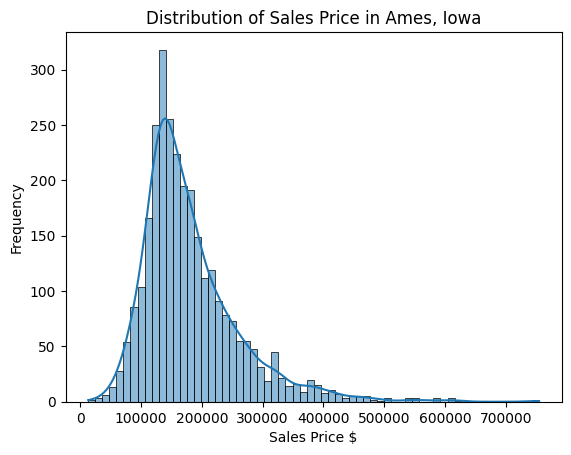

In [142]:
#distribution of sales price
sns.histplot(df["SalePrice"], kde=True)
plt.title("Distribution of Sales Price in Ames, Iowa")
plt.xlabel("Sales Price $")
plt.ylabel("Frequency")
plt.show()

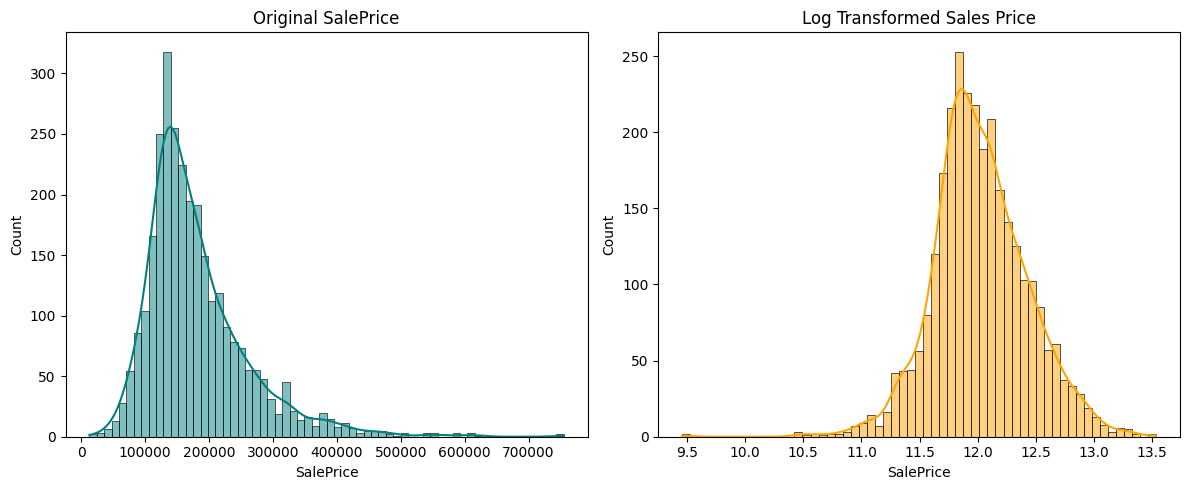

In [143]:
#log transformation of sales price

# Create a figure with two side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Original SalePrice
sns.histplot(df['SalePrice'], kde=True, ax=axes[0], color='teal')
axes[0].set_title('Original SalePrice')

# Plot 2: Log-Transformed SalePrice


sns.histplot(np.log(df["SalePrice"]), kde=True, ax=axes[1], color="orange")
axes[1].set_title("Log Transformed Sales Price")
plt.tight_layout()
plt.show()




In [144]:
# Calculate and print skewness before and after log transformation
print(f"Original Skew: {df['SalePrice'].skew():.2f}")
print(f"Log Skew: {np.log(df['SalePrice']).skew():.2f}")


Original Skew: 1.74
Log Skew: -0.01


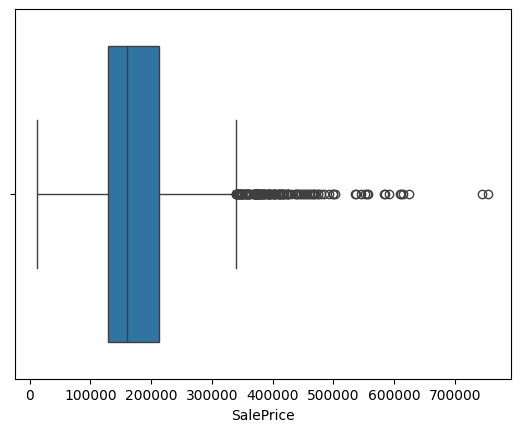

In [145]:
sns.boxplot(x=df['SalePrice'])
plt.show()


In [146]:
# calculate correlation on the numeric columns
# use the log of SalePrice 
df['Log_SalePrice'] = np.log(df['SalePrice'])
numeric_df = df.select_dtypes(include=[np.number])

# Get correlations specifically with Log_SalePrice
correlations = numeric_df.corr()['Log_SalePrice'].sort_values(ascending=False)

print("Top features correlated with House Price:")
print(correlations.head(10))


Top features correlated with House Price:
Log_SalePrice     1.000000
SalePrice         0.946303
Overall Qual      0.825645
Gr Liv Area       0.695862
Garage Cars       0.675318
Garage Area       0.651132
Total Bsmt SF     0.625098
Year Built        0.615484
1st Flr SF        0.602629
Year Remod/Add    0.586153
Name: Log_SalePrice, dtype: float64


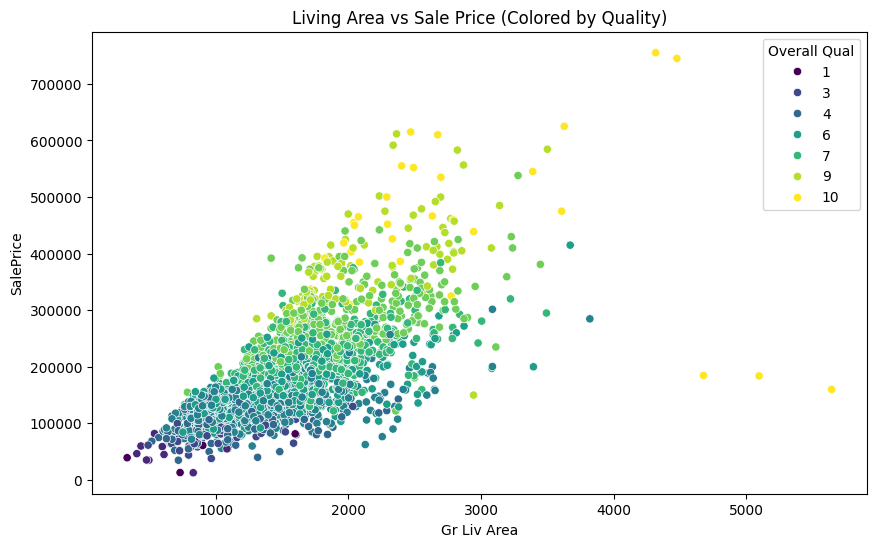

In [147]:
#scatter plot for living area vs sale price colored by overall quality
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Gr Liv Area', y='SalePrice', hue='Overall Qual', palette='viridis')

plt.title('Living Area vs Sale Price (Colored by Quality)')
plt.show()


In [148]:
#identify outliers in the scatter plot for living area 
outliers_livArea = df[(df['Gr Liv Area'] > 4000) & (df['SalePrice'] < 300000)]
print("Number of outliers based on Living Area (> 4000) and Sale Price (< 300000): " + str(len(outliers_livArea)))

df = df.drop(outliers_livArea.index)
print("Number of rows remaining after removing outliers: " + str(len(df)))

Number of outliers based on Living Area (> 4000) and Sale Price (< 300000): 3
Number of rows remaining after removing outliers: 2927


In [149]:
#investigate missing values in the dataset
#mssing values per column
missing_data = df.isnull().sum().sort_values(ascending=False)
missing_data = missing_data[missing_data > 0]

#percentage of missing values per column
missing_percentage = (missing_data / len(df)) * 100

#table of missing values and their percentage
missing_summary = pd.concat([missing_data, missing_percentage], axis=1, keys=['Missing Values', 'Percentage'])
print(missing_summary.head(20))



                Missing Values  Percentage
Pool QC                   2915   99.590024
Misc Feature              2822   96.412709
Alley                     2729   93.235395
Fence                     2355   80.457807
Mas Vnr Type              1775   60.642296
Fireplace Qu              1422   48.582166
Lot Frontage               490   16.740690
Garage Qual                159    5.432183
Garage Cond                159    5.432183
Garage Finish              159    5.432183
Garage Yr Blt              159    5.432183
Garage Type                157    5.363854
Bsmt Exposure               83    2.835668
BsmtFin Type 2              81    2.767339
Bsmt Cond                   80    2.733174
Bsmt Qual                   80    2.733174
BsmtFin Type 1              80    2.733174
Mas Vnr Area                23    0.785787
Bsmt Full Bath               2    0.068329
Bsmt Half Bath               2    0.068329


In [150]:
#list of columns where NaN means "None"
cols_to_fix_none = [
    'Pool QC', 'Misc Feature', 'Alley', 'Fence', 'Fireplace Qu', 
    'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond',
    'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2',
    'Mas Vnr Type'
]

for col in cols_to_fix_none:
    df[col] = df[col].fillna('None')    

In [151]:
#where NaN means 0
cols_to_fix_zero = ['Mas Vnr Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Garage Yr Blt']

for col in cols_to_fix_zero:
    df[col] = df[col].fillna(0)



In [152]:
#investigating NaNs in Lot Frontage
#fill in Nans by the median Lot Frontage of the neighborhood
df['Lot Frontage'] = df.groupby('Neighborhood')['Lot Frontage'].transform(lambda x: x.fillna(x.median()))

#where we dont have a neighborhood median, fill in with the overall median
df['Lot Frontage'] = df['Lot Frontage'].fillna(df['Lot Frontage'].median())

c:\Users\jeric\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\jeric\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [153]:
remaning_missing = df.isnull().sum()
print(f"Total remaining missing values in the dataset: {remaning_missing.sum()}")
print(remaning_missing[remaning_missing > 0])

Total remaining missing values in the dataset: 7
BsmtFin SF 1     1
BsmtFin SF 2     1
Bsmt Unf SF      1
Total Bsmt SF    1
Electrical       1
Garage Cars      1
Garage Area      1
dtype: int64


In [154]:
#fill in the remaining NaNs with 0 since they are all numeric columns and we have no other information to fill them with
remaning_NaNs = ['BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Garage Cars', 'Garage Area']

for col in remaning_NaNs:
    df[col] = df[col].fillna(0)

#fill in electrical with the most common value
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

print(f"Total remaining missing values after all imputation: {df.isnull().sum().sum()}")

Total remaining missing values after all imputation: 0


In [155]:
print(f"There are {len(df.select_dtypes(include=['object']).columns)} categorical features and {len(df.select_dtypes(include=[np.number]).columns)} numeric features in the dataset.")

There are 43 categorical features and 40 numeric features in the dataset.


In [156]:
print(df['Heating QC'].unique())

['Fa' 'TA' 'Ex' 'Gd' 'Po']


In [157]:
print(df['Exter Qual'].unique())

['TA' 'Gd' 'Ex' 'Fa']


In [158]:
#dictionary mapping qua;ity to numerical ranks
quality_mapping = {
    'Ex': 5, #Excellent
    'Gd': 4, #Good
    'TA': 3, #Typical/Average
    'Fa': 2, #Fair
    'Po': 1, #Poor
    'None': 0  #None
}

#apply the mapping to the relevant columns
quality_cols = ['Exter Qual', 'Exter Cond', 'Bsmt Qual', 'Bsmt Cond', 'Heating QC', 
                'Kitchen Qual', 'Fireplace Qu', 'Garage Qual', 'Garage Cond', 'Pool QC']
for col in quality_cols:
    if col in df.columns:
        df[col] = df[col].map(quality_mapping).fillna(0)


In [159]:

#nominal category 
df['MS SubClass'] = df['MS SubClass'].astype(str)

In [160]:
# Identify remaining object/categorical columns that weren't ordinally encoded
nominal_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


# Apply One-Hot Encoding
# drop_first=True prevents the "multicollinearity trap" by dropping one redundant column per feature
df_encoded = pd.get_dummies(df, columns=nominal_cols, drop_first=True)


# Convert boolean True/False outputs from get_dummies to integers (1/0)
df_encoded = df_encoded.astype({col: int for col in df_encoded.columns if df_encoded[col].dtype == 'bool'})

In [168]:
#tran/test split and feature scaling

# 1. Separate your target (SalePrice) from features
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

# 2. Do the Train/Test Split first!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Identify your nominal categorical columns
nominal_cols = [
    'MS SubClass', 'MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 
    'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 
    'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 
    'Mas Vnr Type', 'Foundation', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 
    'Heating', 'Central Air', 'Electrical', 'Functional', 'Garage Type', 'Garage Finish', 
    'Paved Drive', 'Fence', 'Misc Feature', 'Sale Type', 'Sale Condition'
]

# Ordinal columns (Ranked quality/condition -> Map to numbers)
ordinal_cols = [
    'Exter Qual', 'Exter Cond', 'Bsmt Qual', 'Bsmt Cond', 'Heating QC', 
    'Kitchen Qual', 'Fireplace Qu', 'Garage Qual', 'Garage Cond', 'Pool QC'
]

# Filter both lists to only include columns that actually exist in your DataFrame
nominal_cols = [col for col in nominal_cols if col in X_train.columns]
ordinal_cols = [col for col in ordinal_cols if col in X_train.columns]


for col in ordinal_cols:
    X_train.loc[:, col] = X_train[col].map(quality_mapping).fillna(0).astype(int)
    X_test.loc[:, col] = X_test[col].map(quality_mapping).fillna(0).astype(int)

# 4. Initialize the OneHotEncoder
# 'handle_unknown="ignore"' is a lifesaver: if the test set has a category the train set never saw, 
# it just gives it all 0s instead of crashing your program.
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')


# 5. TRANSFORM both train and test sets
train_encoded = encoder.fit_transform(X_train[nominal_cols])
test_encoded = encoder.transform(X_test[nominal_cols])

# 6.  Turn them back into nice DataFrames with column names
encoded_cols = encoder.get_feature_names_out(nominal_cols)
X_train_encoded_df = pd.DataFrame(train_encoded, columns=encoded_cols, index=X_train.index)
X_test_encoded_df = pd.DataFrame(test_encoded, columns=encoded_cols, index=X_test.index)

# 8. Drop the old text columns and join the new one-hot columns
X_train_final = X_train.drop(columns=nominal_cols).join(X_train_encoded_df)
X_test_final = X_test.drop(columns=nominal_cols).join(X_test_encoded_df)

#removing the target variable from the features just in case it got included during preprocessing (it shouldn't have, but better safe than sorry)
X_train_final = X_train_final.drop(columns=['Log_SalePrice'], errors='ignore')
X_test_final = X_test_final.drop(columns=['Log_SalePrice'], errors='ignore')



In [169]:
print(f"Training features shape: {X_train_final.shape}")
print(f"Testing features shape: {X_test_final.shape}")

Training features shape: (2341, 287)
Testing features shape: (586, 287)


In [ ]:
#models

# 1. Initialize the models
lr_model = LinearRegression()
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# ==========================================
# TEST 1: Linear Regression (The Baseline)
# ==========================================
lr_model.fit(X_train_final, y_train)
lr_preds = lr_model.predict(X_test_final)

lr_r2 = r2_score(y_test, lr_preds)
lr_mae = mean_absolute_error(y_test, lr_preds)

# ==========================================
# TEST 2: Random Forest (The Powerhouse)
# ==========================================
rf_model.fit(X_train_final, y_train)
rf_preds = rf_model.predict(X_test_final)

rf_r2 = r2_score(y_test, rf_preds)
rf_mae = mean_absolute_error(y_test, rf_preds)

# ==========================================
# PRINT RESULTS
# ==========================================
print("--- Linear Regression Results ---")
print(f"R² Score (Accuracy): {lr_r2:.4f}")
print(f"Mean Absolute Error: ${lr_mae:,.2f}")
print("\n--- Random Forest Results ---")
print(f"R² Score (Accuracy): {rf_r2:.4f}")
print(f"Mean Absolute Error: ${rf_mae:,.2f}")

--- Linear Regression Results ---
R² Score (Accuracy): 0.9189
Mean Absolute Error: $17,052.75

--- Random Forest Results ---
R² Score (Accuracy): 0.9232
Mean Absolute Error: $15,845.24


In [171]:
# Get feature importances from the Random Forest
importances = rf_model.feature_importances_
feature_names = X_train_final.columns

# Create a DataFrame to rank them
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Look at the top 10 most important features
print(importance_df.head(10))

           Feature  Importance
4     Overall Qual    0.621638
21     Gr Liv Area    0.115831
16   Total Bsmt SF    0.033766
18      1st Flr SF    0.032569
13    BsmtFin SF 1    0.021839
34     Garage Area    0.019612
3         Lot Area    0.017531
24       Full Bath    0.010058
6       Year Built    0.009736
7   Year Remod/Add    0.008939


In [176]:
#creating features to predict the log of the sale price instead of the sale price itself to see if it improves performance
def engineer_housing_features(df):
    #copy the dataframe to avoid modifying the original
    data = df.copy()

    #1. Total Living Area in square feet (1st Flr + 2nd Flr + Basement)
    bast_fin = data['BastFin SF 1'] if 'BamtFin SF 1' in data.columns else 0
    data['Total_Living_Area'] = data['1st Flr SF'] + data['2nd Flr SF'] + bast_fin

    #2. Total Bathrooms (Full + Half)
    data['Total_Baths'] = (
        data['Full Bath'] + 
        0.5 * data['Half Bath'] + 
        data['Bsmt Full Bath'] + 
        0.5 * data['Bsmt Half Bath']
    )

    #3. Age of the house at the time of sale
    data['House_Age_At_Sale'] = data['Yr Sold'] - data['Year Built']

    #make sure there is no negative age due to data issues
    data['House_Age_At_Sale'] = data['House_Age_At_Sale'].apply(lambda x: x if x >= 0 else 0)

    return data

#apply the feature engineering function to both train and test sets
X_train_engineered = engineer_housing_features(X_train_final)
X_test_engineered = engineer_housing_features(X_test_final)

print(f"Training features shape after engineering: {X_train_engineered.shape}")

Training features shape after engineering: (2341, 290)


In [177]:
#retrain the models with the new features and see if performance improves
from sklearn.metrics import r2_score, mean_absolute_error
# 1. Initialize the models
lr_model_eng = LinearRegression()
rf_model_eng = RandomForestRegressor(n_estimators=100, random_state=42)

# ==========================================
# TEST 1: Linear Regression with Engineered Features
lr_model_eng.fit(X_train_engineered, y_train)
lr_preds_eng = lr_model_eng.predict(X_test_engineered)

# ==========================================
# TEST 2: Random Forest with Engineered Features
rf_model_eng.fit(X_train_engineered, y_train)
rf_preds_eng = rf_model_eng.predict(X_test_engineered)

r2_score

# ==========================================    
# PRINT RESULTS
print("--- Linear Regression with Engineered Features ---")
print(f"R² Score: {r2_score(y_test, lr_preds_eng):.4f}")
print(f"Mean Absolute Error: ${mean_absolute_error(y_test, lr_preds_eng):,.2f}")

print("\n--- Random Forest with Engineered Features ---")
print(f"R² Score: {r2_score(y_test, rf_preds_eng):.4f}")
print(f"Mean Absolute Error: ${mean_absolute_error(y_test, rf_preds_eng):,.2f}")    


--- Linear Regression with Engineered Features ---
R² Score: 0.9189
Mean Absolute Error: $17,052.75

--- Random Forest with Engineered Features ---
R² Score: 0.9218
Mean Absolute Error: $15,797.41


In [ ]:


# Define a function to calculate RMSE
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

#list to store model results
model_results = []

# ==========================================
# 1. Lasso Regression 
print("Training Lasso Regression...")
lasso = Lasso(max_iter=10000, random_state=42)
lasso_param_grid = {'alpha': [0.1, 1, 10, 50, 100, 200, 500]}

lasso_cv = GridSearchCV(lasso, lasso_param_grid, scoring='neg_mean_squared_error')
lasso_cv.fit(X_train_engineered, y_train)

lasso_best = lasso_cv.best_estimator_
lasso_preds = lasso_best.predict(X_test_engineered) 
model_results.append({'Model' : 'Lasso Regression', 'RMSE': rmse(y_test, lasso_preds)})

# ==========================================
# 2. Ridge Regression
print("Training Ridge Regression...")
ridge = Ridge(max_iter=10000, random_state=42)
ridge_param_grid = {'alpha': [0.1, 1, 10, 50, 100, 200, 500]}

ridge_cv = GridSearchCV(ridge, ridge_param_grid, scoring='neg_mean_squared_error', cv=5)
ridge_cv.fit(X_train_engineered, y_train)

best_ridge = ridge_cv.best_estimator_
ridge_preds = best_ridge.predict(X_test_engineered)
model_results.append({'Model' : 'Ridge Regression', 'RMSE': rmse(y_test, ridge_preds)})

# ==========================================
# 3. Elastic Net Regression
print("Training Elastic Net Regression...")
elastic = ElasticNet(max_iter=10000, random_state=42)
elastic_param_grid = {
    'alpha': [0.1, 1, 10, 50, 100],
    'l1_ratio': [0.1, 0.5, 0.9] # 0.1 = mostly Ridge, 0.5 = balanced, 0.9 = mostly Lasso
}

elastic_cv = GridSearchCV(elastic, elastic_param_grid, scoring='neg_mean_squared_error', cv=5)
elastic_cv.fit(X_train_engineered, y_train)

best_elastic = elastic_cv.best_estimator_
elastic_preds = best_elastic.predict(X_test_engineered)
model_results.append({'Model' : 'Elastic Net Regression', 'RMSE': rmse(y_test, elastic_preds)})

#=========================================
# Add the Linear Regression and Random Forest results to the model_results list for comparison
try:
    model_results.append({"Model": "Linear Regression", "RMSE": rmse(y_test, lr_preds_eng)})
    model_results.append({"Model": "Random Forest", "RMSE": rmse(y_test, rf_preds_eng)})
except NameError:
    pass  


# Print out the results
print("\n=== 6.4 FINAL MODEL COMPARISON ===")
results_df = pd.DataFrame(model_results).sort_values(by='RMSE')
print(results_df.to_string(index=False))

print(f"\nLasso Best Alpha: {lasso_cv.best_params_['alpha']}")
print(f"Ridge Best Alpha: {ridge_cv.best_params_['alpha']}")
print(f"ElasticNet Best Params: {elastic_cv.best_params_}")



Training Lasso Regression...


c:\Users\jeric\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.813e+11, tolerance: 1.110e+09
  model = cd_fast.enet_coordinate_descent(
c:\Users\jeric\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.876e+11, tolerance: 1.123e+09
  model = cd_fast.enet_coordinate_descent(
c:\Users\jeric\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

Training Ridge Regression...


c:\Users\jeric\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.98313e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\jeric\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.19749e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\jeric\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.19711e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\jeric\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.19612e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\jeric\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\_lib\

Training Elastic Net Regression...


c:\Users\jeric\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.941e+11, tolerance: 1.110e+09
  model = cd_fast.enet_coordinate_descent(
c:\Users\jeric\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.037e+11, tolerance: 1.123e+09
  model = cd_fast.enet_coordinate_descent(
c:\Users\jeric\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca